# Direct GPQR (independent)

In this example, the data generating process is
$$Y = \cos(2 \pi (X+0.1)) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, X+0.1).$$

Quantile functions $Q_{\tau_i}(x)$ of $Y$ are individually modeled latent GP $g_i(x)$:
$$ Q_{\tau_i}(x) = g_i(x; \theta), $$
where 
$$ g_i(x; \theta) \sim \mathcal{N}(\cos(2 \pi x + \theta) + c_i, k(x, x')). $$

Parameters $\theta$ and $c_i$ are learned by maximizing the marginal likelihood.

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.variational import IndependentMultitaskVariationalStrategy
from gpytorch.means import Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.models import DirectQuantileGP
from gpytorch_qr.likelihoods import DirectQuantileLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 10000))

Output will not be deterministic SVG.


## Data preparation

In [ ]:
def f(x):
    return torch.cos((x + 0.1) * 2 * 3.14)


def std(x):
    return x + 0.1


x_range = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
x = x_range.repeat(5, 1)
y = (f(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()

q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)
true_quantiles = f(x_range) + std(x_range) * Normal(0, 1).icdf(q)

x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

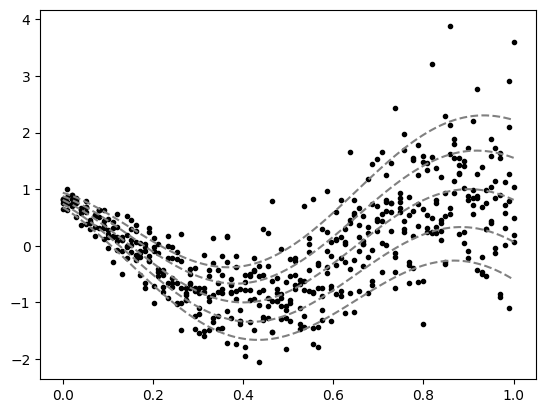

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

In [ ]:
class PriorMean(Mean):
    def __init__(self, batch_shape=torch.Size([])):
        super().__init__()
        self.batch_shape = batch_shape
        self.theta = torch.nn.Parameter(torch.tensor(0.0))
        self.register_parameter("offset", torch.nn.Parameter(torch.zeros(*batch_shape)))

    def forward(self, x):
        # x: (N, D)
        m = torch.cos(2 * 3.14 * x + self.theta)  # (N, D)
        ret = m + self.offset.reshape(*self.offset.shape, 1, 1)  # (B, N, D)
        return ret.squeeze(-1)  # (B, N)


prior_mean = PriorMean(batch_shape=torch.Size([len(q)])).to(device)

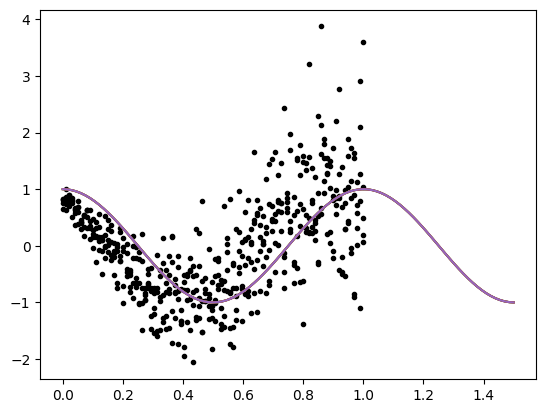

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), prior_mean(x_pred).detach().cpu().T)
plt.show()

## Define models and likelihoods

In [ ]:
class MyGP(DirectQuantileGP):
    def __init__(self, inducing_points, num_quantiles):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_quantiles]),
        )
        variational_strategy = IndependentMultitaskVariationalStrategy(
            UnwhitenedVariationalStrategy(
                self,
                inducing_points,
                variational_distribution,
                learn_inducing_locations=False,
            ),
            num_tasks=num_quantiles,
        )
        mean = PriorMean(batch_shape=torch.Size([num_quantiles]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_quantiles])),
            batch_shape=torch.Size([num_quantiles]),
        )
        super().__init__(variational_strategy, mean, covar)


inducing_points = torch.linspace(0, 1, 10).reshape(-1, 1).to(device)
gp = MyGP(inducing_points, len(q)).to(device)
likelihood = DirectQuantileLikelihood(q).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Evaluate

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles(x_pred)
    lower_q, upper_q = gp.quantile_quantiles(
        x_pred, torch.tensor([0.025, 0.975]).to(device)
    )

## Plot result

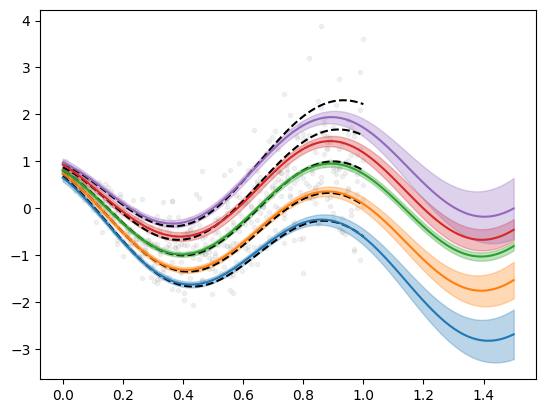

In [ ]:
colors = plt.cm.tab10.colors

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x_range.cpu(), true_quantiles.cpu(), "--", c="k")

for i in range(len(q)):
    plt.plot(x_pred.cpu(), mean_q[:, i].cpu(), color=colors[i])
    plt.fill_between(
        x_pred.cpu().squeeze(),
        lower_q[:, i].cpu(),
        upper_q[:, i].cpu(),
        color=colors[i],
        alpha=0.3,
    )
plt.show()